# Problem

**State space.**
The states are encoded as integers
$$\mathcal{X} = {0,1,\dots,8} $$
corresponding to the grid in row-major order (top-left corner to bottom-right corner).
- State $8$ is the terminal goal state and is absorbing.
- State $5$ is the pit state and is absorbing.
- State $4$ is a wall.


**Action space.**
Actions are represented as integers

$$ \mathcal{A} = {0,1,2,3} $$

where $0 =$ Up, $1 =$ Down, $2 =$ Left, $3 =$ Right.

**Transition dynamics.**
Transitions are deterministic. For any state $x$ and action $a$, the state index is first mapped to its grid coordinates $(r,c)$, the action moves the agent one step (unless this would leave the grid), and the result is mapped back to a state index. The goal state $8$ always transitions to itself.
The transition matrix $P$ has shape $(|\mathcal{X}||\mathcal{A}|) \times |\mathcal{X}| = 36 \times 9$, where each row corresponds to a pair $(x,a)$ and contains a one-hot vector indicating the unique next state:

$$P[(x,a),x'] = 1 \quad \text{iff } x' = \text{next\_state}(x,a)$$

and $0$ otherwise.

**Reward model.**
- $r(x,a) = 1$ if x is a goal state.
- $r(x,a) = -1$ if x is the pit state.
- $r(x,a) = -0.01$ otherwise.

**Initial state.**
The initial state is fixed as $x_0 = 0$.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())

DATASETS_DIR = PROJECT_ROOT / "data" / "datasets_clean"
RESULTS_DIR = PROJECT_ROOT / "data" / "results_clean" / "generalization"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Add project root to the Python path
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.mdp_clean import DiscreteMDP, Planner
from rl_methods.fogas_clean import FOGASEvaluator, FOGASHyperOptimizer
from rl_methods.fogas_generalization_clean import *

/home/mauro/anaconda3/envs/fogas/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Problem

In [2]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)
N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
dataset_path = str(DATASETS_DIR / "3grid_wall.csv")

goal = 8
pit = 5
wall = 4

step_cost = -0.1
goal_reward = 1.0
pit_reward = -1.0


def phi(x, a):
    vec = torch.zeros(N * A, dtype=torch.float64)
    vec[int(x) * A + int(a)] = 1.0
    return vec


omega = torch.full((N * A,), step_cost, dtype=torch.float64)
omega[goal * A : goal * A + A] = goal_reward
omega[pit * A : pit * A + A] = pit_reward


def to_rc(s):
    return divmod(int(s), 3)


def to_s(r, c):
    return r * 3 + c


def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal or s == pit:
        return s

    r, c = to_rc(s)

    if a == 0:      # Up
        r2, c2 = max(0, r - 1), c
    elif a == 1:    # Down
        r2, c2 = min(2, r + 1), c
    elif a == 2:    # Left
        r2, c2 = r, max(0, c - 1)
    elif a == 3:    # Right
        r2, c2 = r, min(2, c + 1)
    else:
        raise ValueError(f"Unknown action: {a}")

    sp = to_s(r2, c2)

    if sp == wall:
        return s

    return sp


def transition_fn(s, a):
    probs = torch.zeros(N, dtype=torch.float64)
    probs[next_state(s, a)] = 1.0
    return probs


mdp = DiscreteMDP(
    states=states,
    actions=actions,
    gamma=gamma,
    x0=x_0,
    omega=omega,
    phi=phi,
    transition_fn=transition_fn,
    terminal_states=[goal, pit],
)

planner = Planner(mdp, mode="deterministic")

# Empirical

## Beta

In [27]:
solver_e = VBetaSolver(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,
    print_params=True,
    T=2000,
    seed=SEED,
    device=DEVICE,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/3grid_wall.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      462.7564263195183
T (iterations):                2000   (overridden → 2000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000621
rho:                            870.919017
eta:                            0.000012
D_theta:                    18.973666
beta (ridge):             0.000014
D_pi (derived):           23.548200




In [29]:
summary_e = optimizer_e.optimize(
    mode="grid",
    parameters=("alpha", "eta", "D_theta", "rho"),
    values={
        "alpha": [1e-4, 1e-3, 1e-2, 1e-1, 1],
        "eta": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
        "rho": [1e-2, 1e-1, 1.0, 10.0, 100.0],
        "D_theta": [0.1, 0.5, 1.0, 5.0, 20.0],
    },
    num_runs=1,
    plot=False,
    print_summary=True,
    progress=True,
    results_output= RESULTS_DIR / "3gridw_vbeta.csv"
)

alpha_star_e = summary_e["best_params"]["alpha"]
eta_star_e = summary_e["best_params"]["eta"]
D_theta_star_e = summary_e["best_params"]["D_theta"]
rho_star_e = summary_e["best_params"]["rho"]

FOGAS hyperopt:   0%|          | 0/750 [00:00<?, ?candidate/s]

FOGAS hyperopt: 100%|██████████| 750/750 [13:11<00:00,  1.06s/candidate, stage=grid, metric=0.966, best=-5.001] 


=== FOGAS Hyperparameter Optimization ===
Metric: average_return
Mode: grid
Parameters: ('alpha', 'eta', 'D_theta', 'rho')
Evaluated candidates: 750
Best metric: -5.00133
Best params: alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04

Top 5 candidates:
1. metric=-5.00133 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04
2. metric=-5.00133 | stage=grid | alpha=1.0000e+00, rho=1.0000e-01, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04
3. metric=-4.92916 | stage=grid | alpha=1.0000e+00, rho=1.0000e-02, eta=1.0000e-03, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04
4. metric=-4.86421 | stage=grid | alpha=1.0000e+00, rho=1.0000e-01, eta=1.0000e-03, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04
5. metric=-4.80575 | stage=grid | alpha=1.0000e+00, rho=1.0000e+00, eta=1.0000e-02, T=2000, D_theta=2.0000e+01, D_pi=4.0000e+04


In [30]:
solver_e.run(
    alpha=alpha_star_e,
    eta=eta_star_e,
    D_theta=D_theta_star_e,
    rho=rho_star_e,
    tqdm_print=True,
)
evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison_e = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison_e["policy"])
print("Optimal average return:", reward_comparison_e["optimal"])
print("Gap:", reward_comparison_e["difference"])

FOGAS: 100%|██████████| 2000/2000 [00:00<00:00, 2650.07it/s]



========== VALUE FUNCTION COMPARISON ==========

Policy mode: solver

State-wise V comparison:
State 0: V*(x) =  6.217100 | V^pi(x) =  6.214433 | delta = -2.667242e-03
State 1: V*(x) =  5.495390 | V^pi(x) = -8.290000 | delta = -1.378539e+01
State 2: V*(x) =  4.845851 | V^pi(x) = -9.100000 | delta = -1.394585e+01
State 3: V*(x) =  7.019000 | V^pi(x) =  7.019000 | delta =  0.000000e+00
State 4: V*(x) =  7.910000 | V^pi(x) = -0.633475 | delta = -8.543475e+00
State 5: V*(x) = -10.000000 | V^pi(x) = -10.000000 | delta =  0.000000e+00
State 6: V*(x) =  7.910000 | V^pi(x) =  7.910000 | delta =  0.000000e+00
State 7: V*(x) =  8.900000 | V^pi(x) =  8.900000 | delta =  0.000000e+00
State 8: V*(x) =  10.000000 | V^pi(x) =  10.000000 | delta =  0.000000e+00

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.492989 | delta = -2.400517e-03
(x=0, a=1): Q*(x,a) =  6.217100 | Q^pi(x,a) =  6.217100 | delta =  0.000000e+00
(x=0, a=2): Q*(x,a) =  5.495390 | Q^pi(x,a) =  5.492989

# Policy

### Objective update

In [31]:
solver_e = VBetaObjectivePolicySolver(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path,
    print_params=True,
    seed=SEED,
    device=DEVICE,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/3grid_wall.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      462.7564263195183
T (iterations):                463

FOGAS Hyperparameters
---------------------
alpha:                        0.001290
rho:                            812.525089
eta:                            0.000025
D_theta:                    18.973666
beta (ridge):             0.000060
D_pi (derived):           11.330086




In [32]:
solver_e.run(
    alpha=1,
    eta=1e-2,
    rho=1e-2,
    D_theta=2,
    T=2000,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
)

evaluator_e.print_solver_policy(policy_mode="solver")

[FOGAS objective-policy] Iter 1/2000 total_loss=-1.000000e-01 policy_loss=-1.000000e-01 theta_norm=2.000000e+00 beta_norm=3.439995e-02 grad_norm=3.440339e+00 policy_grad_norm=2.000000e-01 state_weight_update=normal state_weight_min=0.000000e+00 state_weight_max=1.000000e-01 policy_state_weight_min=0.000000e+00 policy_state_weight_max=1.000000e-01
[FOGAS objective-policy] Iter 51/2000 total_loss=-5.898927e-02 policy_loss=-6.775560e-02 theta_norm=2.000000e+00 beta_norm=1.528020e+00 grad_norm=2.901313e+00 policy_grad_norm=1.289928e-01 state_weight_update=normal state_weight_min=-5.459285e-03 state_weight_max=8.725749e-02 policy_state_weight_min=-5.459285e-03 policy_state_weight_max=8.725749e-02
[FOGAS objective-policy] Iter 101/2000 total_loss=-5.328195e-02 policy_loss=-6.053092e-02 theta_norm=2.000000e+00 beta_norm=2.930209e+00 grad_norm=2.860932e+00 policy_grad_norm=1.154707e-01 state_weight_update=normal state_weight_min=-1.206510e-02 state_weight_max=9.053212e-02 policy_state_weight_m

Same thing! This new weights do that the policy update is not that strong in the not that well covered states.

In [35]:
solver_e.run(
    alpha=1,
    eta=1e-2,
    rho=1e-2,
    D_theta=2,
    T=2000,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    state_weight_update="clipped",
    c_min=0.2,
)
evaluator_e.print_solver_policy(policy_mode="solver")

[FOGAS objective-policy] Iter 1/2000 total_loss=-1.000000e-01 policy_loss=-2.000000e-01 theta_norm=2.000000e+00 beta_norm=3.439995e-02 grad_norm=3.440339e+00 policy_grad_norm=4.000000e-01 state_weight_update=clipped state_weight_min=0.000000e+00 state_weight_max=1.000000e-01 policy_state_weight_min=2.000000e-01 policy_state_weight_max=2.000000e-01
[FOGAS objective-policy] Iter 51/2000 total_loss=-5.620110e-02 policy_loss=-3.068897e-01 theta_norm=2.000000e+00 beta_norm=1.531237e+00 grad_norm=2.892793e+00 policy_grad_norm=4.000000e-01 state_weight_update=clipped state_weight_min=-3.328251e-03 state_weight_max=8.450577e-02 policy_state_weight_min=2.000000e-01 policy_state_weight_max=2.000000e-01
[FOGAS objective-policy] Iter 101/2000 total_loss=-5.062181e-02 policy_loss=-3.342148e-01 theta_norm=2.000000e+00 beta_norm=2.922572e+00 grad_norm=2.845003e+00 policy_grad_norm=4.000000e-01 state_weight_update=clipped state_weight_min=-3.842192e-03 state_weight_max=8.699251e-02 policy_state_weight

Much better clipping!

c_min seed sweep: 100%|██████████| 24/24 [00:46<00:00,  1.96s/run]

Saved CSV to: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results_clean/generalization/3gridw_vbeta_objective_policy_cmin_seed_sweep.csv

Best config by mean average return:


,label,state_weight_update,c_min,n,mean_return,std_return,best_return,mean_gap,ci95
3,clipped c_min=0.05,clipped,0.05,3,0.462707,0.0,0.462707,4.538627,0.0



All configs:


,label,state_weight_update,c_min,n,mean_return,std_return,best_return,mean_gap,ci95
3,clipped c_min=0.05,clipped,0.05,3,0.462707,0.000000,0.462707,4.538627,0.000000
4,clipped c_min=0.1,clipped,0.10,3,0.462707,0.000000,0.462707,4.538627,0.000000
5,clipped c_min=0.2,clipped,0.20,3,0.462707,0.000000,0.462707,4.538627,0.000000
2,clipped c_min=0.02,clipped,0.02,3,0.390536,0.072171,0.462707,4.610798,0.179297
1,clipped c_min=0.01,clipped,0.01,3,0.164575,0.138536,0.319021,4.836759,0.344171
6,clipped c_min=0.5,clipped,0.50,3,-0.293731,0.655094,0.462707,5.295065,1.627476
7,normal,normal,NaN,3,-0.878423,0.000000,-0.878423,5.879757,0.000000
0,clipped c_min=0.0,clipped,0.00,3,-3.651320,0.091136,-3.565298,8.652654,0.226412


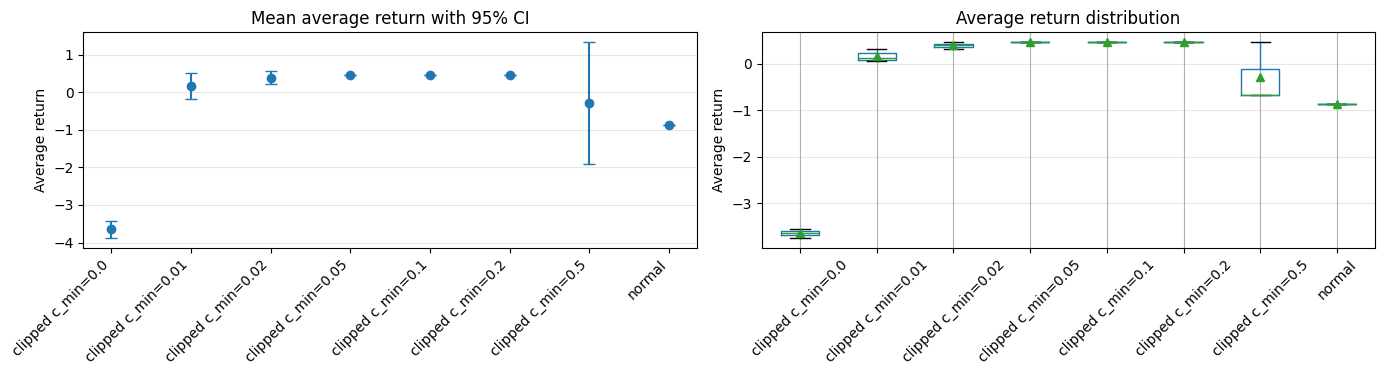

In [36]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Fixed hyperparameters
fixed_params = {
    "alpha": 1.0,
    "eta": 1e-2,
    "rho": 1e-2,
    "D_theta": 2.0,
    "T": 2000,
}

# Three seeds, including SEED
seeds = [SEED, SEED + 1, SEED + 2]

# One normal/non-clipped baseline + clipped c_min values
configs = [{"state_weight_update": "normal", "c_min": np.nan, "label": "normal"}]
configs += [
    {"state_weight_update": "clipped", "c_min": c, "label": f"clipped c_min={c}"}
    for c in [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
]

rows = []
jobs = [(cfg, run_seed) for cfg in configs for run_seed in seeds]

for cfg, run_seed in tqdm(jobs, desc="c_min seed sweep", unit="run"):
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    solver = VBetaObjectivePolicySolver(
        mdp=mdp,
        phi=phi,
        csv_path=dataset_path,
        print_params=False,
        seed=run_seed,
        device=DEVICE,
    )

    evaluator = FOGASEvaluator(
        solver=solver,
        mdp=mdp,
        planner=planner,
    )

    run_kwargs = dict(
        **fixed_params,
        tqdm_print=False,
        verbose=False,
        state_weight_update=cfg["state_weight_update"],
    )

    if cfg["state_weight_update"] == "clipped":
        run_kwargs["c_min"] = float(cfg["c_min"])

    solver.run(**run_kwargs)

    # Same metric convention as optimizer_e: no terminal_states
    result = evaluator.average_return(
        policy_mode="solver",
        num_trajectories=10,
        max_steps=20,
        seed=run_seed,
        compare_with_optimal=True,
    )

    rows.append({
        "label": cfg["label"],
        "state_weight_update": cfg["state_weight_update"],
        "c_min": cfg["c_min"],
        "seed": run_seed,
        "average_return": result["policy"],
        "optimal_return": result["optimal"],
        "gap": result["difference"],
        **fixed_params,
    })

results_df = pd.DataFrame(rows)

output_path = RESULTS_DIR / "3gridw_vbeta_objective_policy_cmin_seed_sweep.csv"
results_df.to_csv(output_path, index=False)

summary_df = (
    results_df
    .groupby(["label", "state_weight_update", "c_min"], dropna=False)
    .agg(
        n=("average_return", "count"),
        mean_return=("average_return", "mean"),
        std_return=("average_return", "std"),
        best_return=("average_return", "max"),
        mean_gap=("gap", "mean"),
    )
    .reset_index()
)

# 95% CI with n=3: t_{0.975,2} ~= 4.303
summary_df["ci95"] = 4.303 * summary_df["std_return"].fillna(0.0) / np.sqrt(summary_df["n"])

best = summary_df.sort_values("mean_return", ascending=False).iloc[0]

print(f"Saved CSV to: {output_path}")
print("\nBest config by mean average return:")
display(best.to_frame().T)

print("\nAll configs:")
display(summary_df.sort_values("mean_return", ascending=False))

plot_df = summary_df.copy()
plot_df["x_label"] = plot_df["label"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].errorbar(
    x=np.arange(len(plot_df)),
    y=plot_df["mean_return"],
    yerr=plot_df["ci95"],
    fmt="o",
    capsize=4,
)
axes[0].set_xticks(np.arange(len(plot_df)))
axes[0].set_xticklabels(plot_df["x_label"], rotation=45, ha="right")
axes[0].set_ylabel("Average return")
axes[0].set_title("Mean average return with 95% CI")
axes[0].grid(axis="y", alpha=0.3)

results_df.boxplot(
    column="average_return",
    by="label",
    ax=axes[1],
    showmeans=True,
)
axes[1].set_title("Average return distribution")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average return")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("")
plt.tight_layout()
plt.show()

### Tabular SGD/Adam

In [38]:
policy_features = TabularPolicyFeatures(mdp.N, mdp.A)

solver_e = LinearPolicyFOGAS(
    mdp=mdp,
    phi=phi,
    csv_path=dataset_path, 
    print_params=True,
    seed=SEED,
    device=DEVICE,
    policy_features=policy_features,
)

evaluator_e = FOGASEvaluator(
    solver=solver_e,
    mdp=mdp,
    planner=planner,
)

optimizer_e = FOGASHyperOptimizer(
    solver=solver_e,
    evaluator=evaluator_e,
    metric="average_return",
    metric_kwargs={
        "policy_mode": "solver",
        "num_trajectories": 10,
        "max_steps": 20,
        "seed": SEED,
        "maximize": True,
    },
    seed=SEED,
)


Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/datasets_clean/3grid_wall.csv (n=500)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           500
Feature norm bound R:     1.0000
Num states N:             9
Num actions A:            4
Feature dim d:            36
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      462.7564263195183
T (iterations):                463

FOGAS Hyperparameters
---------------------
alpha:                        0.001290
rho:                            812.525089
eta:                            0.000025
D_theta:                    18.973666
beta (ridge):             0.000060
D_pi (derived):           11.330086




In [51]:
solver_e.run(
    alpha=1e-3,
    eta=1e-2,
    rho=1e-2,
    D_theta=2,
    T=10000,
    policy_optimizer="adam",  # or "adam"
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    state_weight_update="clipped",
    c_min=0.2,
)

evaluator_e.compare_value_functions(policy_mode="solver")

reward_comparison = evaluator_e.average_return(
    policy_mode="solver",
    num_trajectories=10,
    max_steps=20,
    seed=SEED,
    compare_with_optimal=True,
)

print("Solver average return:", reward_comparison["policy"])
print("Optimal average return:", reward_comparison["optimal"])
print("Gap:", reward_comparison["difference"])

[FOGAS linear-policy] Iter 1/10000 total_loss=-1.000000e-01 policy_objective=-2.000000e-01 theta_norm=2.000000e+00 beta_norm=3.439995e-02 grad_norm=3.440339e+00 policy_grad_norm=0.000000e+00 psi_norm=0.000000e+00 policy_optimizer=adam state_weight_update=clipped state_weight_min=0.000000e+00 state_weight_max=1.000000e-01 policy_state_weight_min=2.000000e-01 policy_state_weight_max=2.000000e-01
[FOGAS linear-policy] Iter 51/10000 total_loss=-6.289099e-02 policy_objective=-3.083141e-01 theta_norm=2.000000e+00 beta_norm=1.524173e+00 grad_norm=2.903747e+00 policy_grad_norm=3.800985e-02 psi_norm=2.761934e-01 policy_optimizer=adam state_weight_update=clipped state_weight_min=-5.830608e-03 state_weight_max=9.161685e-02 policy_state_weight_min=2.000000e-01 policy_state_weight_max=2.000000e-01
[FOGAS linear-policy] Iter 101/10000 total_loss=-5.651912e-02 policy_objective=-3.335960e-01 theta_norm=2.000000e+00 beta_norm=2.931918e+00 grad_norm=2.863618e+00 policy_grad_norm=3.387997e-02 psi_norm=5.

In [52]:
evaluator_e.print_solver_policy(policy_mode="solver")

  State 0: pi(a=0|s=0) = 0.00  pi(a=1|s=0) = 0.75  pi(a=2|s=0) = 0.00  pi(a=3|s=0) = 0.24  --> best action: 1
  State 1: pi(a=0|s=1) = 0.00  pi(a=1|s=1) = 0.00  pi(a=2|s=1) = 0.00  pi(a=3|s=1) = 1.00  --> best action: 3
  State 2: pi(a=0|s=2) = 0.00  pi(a=1|s=2) = 1.00  pi(a=2|s=2) = 0.00  pi(a=3|s=2) = 0.00  --> best action: 1
  State 3: pi(a=0|s=3) = 0.00  pi(a=1|s=3) = 1.00  pi(a=2|s=3) = 0.00  pi(a=3|s=3) = 0.00  --> best action: 1
  State 4: pi(a=0|s=4) = 0.25  pi(a=1|s=4) = 0.25  pi(a=2|s=4) = 0.25  pi(a=3|s=4) = 0.25  --> best action: 0
  State 5: pi(a=0|s=5) = 0.25  pi(a=1|s=5) = 0.25  pi(a=2|s=5) = 0.25  pi(a=3|s=5) = 0.25  --> best action: 0
  State 6: pi(a=0|s=6) = 0.00  pi(a=1|s=6) = 0.00  pi(a=2|s=6) = 0.00  pi(a=3|s=6) = 1.00  --> best action: 3
  State 7: pi(a=0|s=7) = 0.01  pi(a=1|s=7) = 0.00  pi(a=2|s=7) = 0.00  pi(a=3|s=7) = 0.99  --> best action: 3
  State 8: pi(a=0|s=8) = 0.25  pi(a=1|s=8) = 0.25  pi(a=2|s=8) = 0.25  pi(a=3|s=8) = 0.25  --> best action: 0



Here Adam is much better than SGD and we can notice the accumulation of momentum and we have higuer probabilities in optimal states.

In [ ]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt

alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1]
policy_optimizers = ["sgd", "adam"]

results = []

for alpha, policy_optimizer in itertools.product(alphas, policy_optimizers):
    print(f"\nRunning alpha={alpha:.0e}, policy_optimizer={policy_optimizer}")

    solver_e.run(
        alpha=alpha,
        eta=1e-2,
        rho=1e-2,
        D_theta=2,
        T=10000,
        policy_optimizer=policy_optimizer,
        tqdm_print=False,
        verbose=False,
        log_interval=50,
        state_weight_update="clipped",
        c_min=0.2,
    )

    metric_result = evaluator_e.average_return(
        policy_mode="solver",
        num_trajectories=10,
        max_steps=20,
        seed=SEED,
    )

    avg_return = metric_result["policy"]

    results.append(
        {
            "alpha": alpha,
            "policy_optimizer": policy_optimizer,
            "average_return": avg_return,
        }
    )

results_df = pd.DataFrame(results)
results_df


Running alpha=1e-05, policy_optimizer=sgd

Running alpha=1e-05, policy_optimizer=adam

Running alpha=1e-04, policy_optimizer=sgd

Running alpha=1e-04, policy_optimizer=adam

Running alpha=1e-03, policy_optimizer=sgd

Running alpha=1e-03, policy_optimizer=adam

Running alpha=1e-02, policy_optimizer=sgd

Running alpha=1e-02, policy_optimizer=adam

Running alpha=1e-01, policy_optimizer=sgd

Running alpha=1e-01, policy_optimizer=adam

Running alpha=1e+00, policy_optimizer=sgd

Running alpha=1e+00, policy_optimizer=adam


,alpha,policy_optimizer,average_return
0,0.00001,sgd,-1.678870
1,0.00001,adam,-2.900692
2,0.00010,sgd,-1.678870
3,0.00010,adam,-0.039768
4,0.00100,sgd,-2.076010
5,0.00100,adam,2.732020
6,0.01000,sgd,-2.596200
7,0.01000,adam,2.732020
8,0.10000,sgd,2.385599
9,0.10000,adam,2.732020


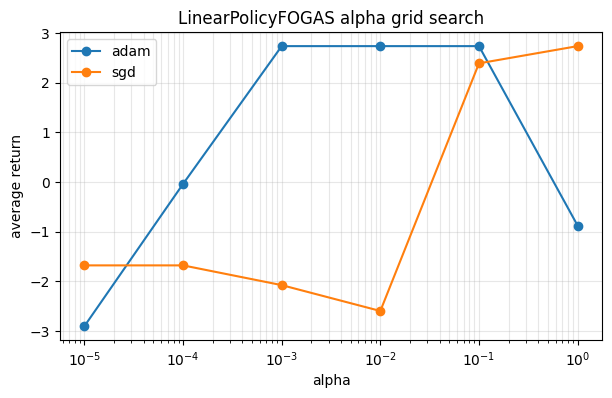

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))

for policy_optimizer, group in results_df.groupby("policy_optimizer"):
    group = group.sort_values("alpha")
    ax.plot(
        group["alpha"],
        group["average_return"],
        marker="o",
        label=policy_optimizer,
    )

ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("average return")
ax.set_title("LinearPolicyFOGAS alpha grid search")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

In [50]:
best_row = results_df.loc[results_df["average_return"].idxmax()]
print(best_row)

alpha                 0.001
policy_optimizer       adam
average_return      2.73202
Name: 5, dtype: object


## Beta update

### Linear $u_{\beta}$ adaptation

In [30]:
u_features = TabularPolicyFeatures(N, A)
policy_features = TabularPolicyFeatures(N, A)

solver_e = LinearBetaPiSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearUFunction(u_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,
)

In [31]:
solver_e.run(
    alpha=1e-3,
    eta=2e-4,
    rho=0.5,
    policy_optimizer="adam",
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2000,
    state_weight_update="clipped",
    c_min=0.5,
)

[FOGAS linear-beta-pi] Iter 1/2000 total_loss=-9.486833e-01 policy_objective=-4.743416e+00 theta_norm=1.897367e+01 beta_norm=3.640129e-03 grad_norm=1.820247e+01 policy_grad_norm=0.000000e+00 psi_norm=0.000000e+00 policy_optimizer=adam state_weight_update=clipped state_weight_min=0.000000e+00 state_weight_max=1.000000e-01 policy_state_weight_min=5.000000e-01 policy_state_weight_max=5.000000e-01
[FOGAS linear-beta-pi] Iter 51/2000 total_loss=-7.922087e-01 policy_objective=-5.577755e+00 theta_norm=1.897367e+01 beta_norm=1.673958e-01 grad_norm=1.476893e+01 policy_grad_norm=3.031775e-01 psi_norm=3.056773e-01 policy_optimizer=adam state_weight_update=clipped state_weight_min=-1.013934e-03 state_weight_max=9.643587e-02 policy_state_weight_min=5.000000e-01 policy_state_weight_max=5.000000e-01
[FOGAS linear-beta-pi] Iter 101/2000 total_loss=-6.911267e-01 policy_objective=-6.202983e+00 theta_norm=1.897367e+01 beta_norm=2.965224e-01 grad_norm=1.175470e+01 policy_grad_norm=4.962780e-01 psi_norm=6.

tensor([[0.1219, 0.4835, 0.1265, 0.2681],
        [0.1912, 0.2211, 0.0875, 0.5003],
        [0.2423, 0.5308, 0.0130, 0.2138],
        [0.0752, 0.6737, 0.1178, 0.1333],
        [0.2500, 0.2500, 0.2500, 0.2500],
        [0.0291, 0.4791, 0.0127, 0.4791],
        [0.0414, 0.1201, 0.1225, 0.7160],
        [0.1583, 0.1640, 0.0437, 0.6339],
        [0.2500, 0.2500, 0.2500, 0.2500]])

In [29]:
mdp.print_policy(solver_e.pi)

  State 0: π(a=0|s=0) = 0.12  π(a=1|s=0) = 0.48  π(a=2|s=0) = 0.13  π(a=3|s=0) = 0.27  --> best action: 1
  State 1: π(a=0|s=1) = 0.19  π(a=1|s=1) = 0.22  π(a=2|s=1) = 0.09  π(a=3|s=1) = 0.50  --> best action: 3
  State 2: π(a=0|s=2) = 0.24  π(a=1|s=2) = 0.53  π(a=2|s=2) = 0.01  π(a=3|s=2) = 0.21  --> best action: 1
  State 3: π(a=0|s=3) = 0.08  π(a=1|s=3) = 0.67  π(a=2|s=3) = 0.12  π(a=3|s=3) = 0.13  --> best action: 1
  State 4: π(a=0|s=4) = 0.25  π(a=1|s=4) = 0.25  π(a=2|s=4) = 0.25  π(a=3|s=4) = 0.25  --> best action: 0
  State 5: π(a=0|s=5) = 0.03  π(a=1|s=5) = 0.48  π(a=2|s=5) = 0.01  π(a=3|s=5) = 0.48  --> best action: 1
  State 6: π(a=0|s=6) = 0.04  π(a=1|s=6) = 0.12  π(a=2|s=6) = 0.12  π(a=3|s=6) = 0.72  --> best action: 3
  State 7: π(a=0|s=7) = 0.16  π(a=1|s=7) = 0.16  π(a=2|s=7) = 0.04  π(a=3|s=7) = 0.63  --> best action: 3
  State 8: π(a=0|s=8) = 0.25  π(a=1|s=8) = 0.25  π(a=2|s=8) = 0.25  π(a=3|s=8) = 0.25  --> best action: 0



## Theta update

### Loss dependency beta regularizer

In [33]:
u_features = TabularPolicyFeatures(N, A)
policy_features = TabularPolicyFeatures(N, A)

solver_e = LossThetaBetaPiSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearUFunction(u_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,
)

In [34]:
solver_e.run(
    alpha=1e-3,
    eta=2e-4,
    rho=0.5,
    policy_optimizer="adam",
    tqdm_print=False,
    verbose=False,
    log_interval=50,
    T=2000,
    state_weight_update="clipped",
    c_min=0.5,
    theta_loss_include_beta_reg=True,
)
mdp.print_policy(solver_e.pi)

  State 0: π(a=0|s=0) = 0.12  π(a=1|s=0) = 0.48  π(a=2|s=0) = 0.13  π(a=3|s=0) = 0.27  --> best action: 1
  State 1: π(a=0|s=1) = 0.19  π(a=1|s=1) = 0.22  π(a=2|s=1) = 0.09  π(a=3|s=1) = 0.50  --> best action: 3
  State 2: π(a=0|s=2) = 0.24  π(a=1|s=2) = 0.53  π(a=2|s=2) = 0.01  π(a=3|s=2) = 0.21  --> best action: 1
  State 3: π(a=0|s=3) = 0.08  π(a=1|s=3) = 0.67  π(a=2|s=3) = 0.12  π(a=3|s=3) = 0.13  --> best action: 1
  State 4: π(a=0|s=4) = 0.25  π(a=1|s=4) = 0.25  π(a=2|s=4) = 0.25  π(a=3|s=4) = 0.25  --> best action: 0
  State 5: π(a=0|s=5) = 0.03  π(a=1|s=5) = 0.48  π(a=2|s=5) = 0.01  π(a=3|s=5) = 0.48  --> best action: 1
  State 6: π(a=0|s=6) = 0.04  π(a=1|s=6) = 0.12  π(a=2|s=6) = 0.12  π(a=3|s=6) = 0.72  --> best action: 3
  State 7: π(a=0|s=7) = 0.16  π(a=1|s=7) = 0.16  π(a=2|s=7) = 0.04  π(a=3|s=7) = 0.63  --> best action: 3
  State 8: π(a=0|s=8) = 0.25  π(a=1|s=8) = 0.25  π(a=2|s=8) = 0.25  π(a=3|s=8) = 0.25  --> best action: 0



In [35]:
solver_e.run(
    alpha=1e-3,
    eta=2e-4,
    rho=0.5,
    policy_optimizer="adam",
    tqdm_print=False,
    verbose=False,
    log_interval=50,
    T=2000,
    state_weight_update="clipped",
    c_min=0.5,
    theta_loss_include_beta_reg=False,
)
mdp.print_policy(solver_e.pi)

  State 0: π(a=0|s=0) = 0.12  π(a=1|s=0) = 0.48  π(a=2|s=0) = 0.13  π(a=3|s=0) = 0.27  --> best action: 1
  State 1: π(a=0|s=1) = 0.19  π(a=1|s=1) = 0.22  π(a=2|s=1) = 0.09  π(a=3|s=1) = 0.50  --> best action: 3
  State 2: π(a=0|s=2) = 0.24  π(a=1|s=2) = 0.53  π(a=2|s=2) = 0.01  π(a=3|s=2) = 0.21  --> best action: 1
  State 3: π(a=0|s=3) = 0.08  π(a=1|s=3) = 0.67  π(a=2|s=3) = 0.12  π(a=3|s=3) = 0.13  --> best action: 1
  State 4: π(a=0|s=4) = 0.25  π(a=1|s=4) = 0.25  π(a=2|s=4) = 0.25  π(a=3|s=4) = 0.25  --> best action: 0
  State 5: π(a=0|s=5) = 0.03  π(a=1|s=5) = 0.48  π(a=2|s=5) = 0.01  π(a=3|s=5) = 0.48  --> best action: 1
  State 6: π(a=0|s=6) = 0.04  π(a=1|s=6) = 0.12  π(a=2|s=6) = 0.12  π(a=3|s=6) = 0.72  --> best action: 3
  State 7: π(a=0|s=7) = 0.16  π(a=1|s=7) = 0.16  π(a=2|s=7) = 0.04  π(a=3|s=7) = 0.63  --> best action: 3
  State 8: π(a=0|s=8) = 0.25  π(a=1|s=8) = 0.25  π(a=2|s=8) = 0.25  π(a=3|s=8) = 0.25  --> best action: 0



No change neither!

### Regularized update

Same of 3 grid, adaptive for sure and adam works much better than SGD, but there is the need of more steps to do the best update.

In [14]:
u_features = TabularPolicyFeatures(N, A)
policy_features = TabularPolicyFeatures(N, A)

solver_e = RegularizedLossThetaBetaPiSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearUFunction(u_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,
)

solver_e.run(
    alpha=1e-3,
    eta=2e-4,
    rho=0.5,
    policy_optimizer="adam",
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2000,
    state_weight_update="clipped",
    c_min=0.5,
    theta_loss_include_beta_reg=False,
    theta_update="adam",
    theta_lambda_mode="adaptive",
    theta_lr=1e-2,          
    theta_inner_steps=50, 
)

mdp.print_policy(solver_e.pi)


[FOGAS linear-beta-pi] Iter 1/2000 total_loss=-4.967739e-02 policy_objective=-2.483869e-01 theta_norm=9.935478e-01 beta_norm=4.421997e-04 grad_norm=2.211220e+00 policy_grad_norm=0.000000e+00 psi_norm=0.000000e+00 policy_optimizer=adam state_weight_update=clipped state_weight_min=0.000000e+00 state_weight_max=1.000000e-01 policy_state_weight_min=5.000000e-01 policy_state_weight_max=5.000000e-01
[FOGAS linear-beta-pi] Iter 51/2000 total_loss=-4.812170e-02 policy_objective=-2.990328e-01 theta_norm=1.004590e+00 beta_norm=2.222961e-02 grad_norm=2.161038e+00 policy_grad_norm=7.858170e-03 psi_norm=2.485709e-01 policy_optimizer=adam state_weight_update=clipped state_weight_min=-1.014115e-03 state_weight_max=9.978093e-02 policy_state_weight_min=5.000000e-01 policy_state_weight_max=5.000000e-01
[FOGAS linear-beta-pi] Iter 101/2000 total_loss=-4.669793e-02 policy_objective=-3.396650e-01 theta_norm=1.027951e+00 beta_norm=4.349197e-02 grad_norm=2.128029e+00 policy_grad_norm=1.210019e-02 psi_norm=5.

# Linear

In [3]:
u_features = TabularFeatures(N, A)
q_features = TabularFeatures(N, A)
policy_features = TabularFeatures(N, A)

solver_e = LinearSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearFunction(u_features),
    q_function=LinearQFunction(q_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,
    theta_loss_include_beta_reg=False,
    theta_update="adam",
    theta_lr=1e-2,
    theta_inner_steps=100,
    d_theta_scale=1.0,
)

In [4]:
solver_e.run(
    alpha=1e-3,
    eta=2e-4,
    rho=0.5,
    policy_optimizer="adam",
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2000,
    state_weight_update="clipped",
    c_min=0.5,
)

mdp.print_policy(solver_e.pi)

[LinearSolver] Iter 1/2000 iter=0 total_loss=-9.815896e-02 policy_objective=-4.907948e-01 beta_objective=0.000000e+00 q_objective=-9.308077e-02 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=1.268984e-01 theta_grad_norm=4.482657e-02 policy_optimizer=adam policy_gradient=exact policy_direction=adam_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 51/2000 iter=50 total_loss=-9.631968e-02 policy_objective=-5.942032e-01 beta_objective=1.838953e-03 q_objective=-9.121120e-02 policy_grad_norm=2.227436e-02 policy_direction_norm=2.227436e-02 beta_grad_norm=1.092430e-01 theta_grad_norm=4.384962e-02 policy_optimizer=adam policy_gradient=exact policy_direction=adam_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 101/2000 iter=100 total_loss=-9.519335e-02 policy_objective=-6.783513e-01 beta_objective=2.964536e-03 q_objective=-8.983772e-02 policy_grad_norm=3.57402

### REINFORCE

In [5]:
solver_e.run(
    alpha=1e-3,
    eta=2e-4,
    rho=0.5,
    policy_optimizer="adam",
    policy_gradient="reinforce",
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2000,
    state_weight_update="clipped",
    c_min=0.5,
)

mdp.print_policy(solver_e.pi)

[LinearSolver] Iter 1/2000 iter=0 total_loss=-9.815896e-02 policy_objective=-4.907948e-01 beta_objective=0.000000e+00 q_objective=-9.308077e-02 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=1.362028e-01 theta_grad_norm=4.482657e-02 policy_optimizer=adam policy_gradient=reinforce policy_direction=adam_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 51/2000 iter=50 total_loss=-9.532612e-02 policy_objective=-5.849117e-01 beta_objective=2.832625e-03 q_objective=-9.135939e-02 policy_grad_norm=1.371907e-02 policy_direction_norm=1.371907e-02 beta_grad_norm=1.251093e-01 theta_grad_norm=4.394737e-02 policy_optimizer=adam policy_gradient=reinforce policy_direction=adam_gradient reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01
[LinearSolver] Iter 101/2000 iter=100 total_loss=-9.300270e-02 policy_objective=-6.685857e-01 beta_objective=5.155466e-03 q_objective=-8.998525e-02 policy_grad_norm

### NPG

In [5]:
solver_e.run(
    alpha=1e-2,  
    eta=2e-4,
    rho=0.5,
    policy_optimizer="npg",
    policy_gradient="reinforce",
    reinforce_samples=1,
    fisher_damping=1e-3,
    cg_iters=10,
    cg_tol=1e-10,
    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2000,
    state_weight_update="clipped",
    c_min=0.5,
)

mdp.print_policy(solver_e.pi)

[LinearSolver] Iter 1/2000 iter=0 total_loss=-9.815896e-02 policy_objective=-4.907948e-01 beta_objective=0.000000e+00 q_objective=-9.308077e-02 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=1.268984e-01 theta_grad_norm=4.482657e-02 policy_optimizer=npg policy_gradient=reinforce policy_direction=cg_fisher reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01 cg_iters_used=0 cg_residual_norm=0.000000e+00 cg_relative_residual=0.000000e+00
[LinearSolver] Iter 51/2000 iter=50 total_loss=-9.631709e-02 policy_objective=-5.932734e-01 beta_objective=1.840987e-03 q_objective=-9.120922e-02 policy_grad_norm=1.808302e-02 policy_direction_norm=6.162718e-01 beta_grad_norm=1.093502e-01 theta_grad_norm=4.385417e-02 policy_optimizer=npg policy_gradient=reinforce policy_direction=cg_fisher reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e+01 cg_iters_used=6 cg_residual_norm=1.447085e-12 cg_relative_residual=8.002453e-11
[LinearSolver]

# Final Solver

In [16]:
from rl_methods.fogas_generalization_clean import (
    FinalLinearSolver,
    TabularFeatures,
    LinearFunction,
    LinearQFunction,
)

u_features = TabularFeatures(N, A)
q_features = TabularFeatures(N, A)
policy_features = TabularFeatures(N, A)

solver_e = FinalLinearSolver(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    x0=x_0,
    csv_path=dataset_path,
    u_function=LinearFunction(u_features),
    q_function=LinearQFunction(q_features),
    policy_features=policy_features,
    seed=SEED,
    device=DEVICE,

    # Old LinearSolver equivalent:
    # theta_loss_include_beta_reg=False
    theta_include_beta_cov=False,

    # Old theta_update="adam" becomes optimizer choice.
    theta_mode="projection",
    theta_optimizer="adam",
    theta_lr=1e-2,
    theta_inner_steps=100,
    theta_start_mode="zero",
    d_theta_scale=0.001,

    # Old beta behavior.
    beta_update="fogas_full",
)

solver_e.run(
    alpha=1e-2,
    eta=2e-4,
    rho=0.5,

    policy_optimizer="npg",
    policy_gradient="reinforce",
    reinforce_samples=1,
    fisher_damping=1e-3,
    cg_iters=10,
    cg_tol=1e-10,

    tqdm_print=False,
    verbose=True,
    log_interval=50,
    T=2000,

    state_weight_update="normal"
    )

mdp.print_policy(solver_e.pi)

[FinalLinearSolver] Iter 1/2000 iter=0 total_loss=-9.486833e-04 policy_objective=-9.486833e-04 beta_objective=0.000000e+00 q_objective=-9.486833e-04 policy_grad_norm=0.000000e+00 policy_direction_norm=0.000000e+00 beta_grad_norm=2.329896e-02 beta_direction_norm=4.894187e-01 theta_grad_norm=5.000000e-02 theta_norm=1.897367e-02 theta_mode=projection theta_optimizer=adam theta_start_mode=zero theta_lambda=None theta_lr=1.000000e-02 theta_include_beta_cov=False policy_optimizer=npg policy_gradient=reinforce policy_direction=cg_fisher reinforce_samples=1 D_theta=1.897367e+01 effective_D_theta=1.897367e-02 beta_update=fogas_full beta_diag_min=None beta_diag_max=None cg_iters_used=0 cg_residual_norm=0.000000e+00 cg_relative_residual=0.000000e+00
[FinalLinearSolver] Iter 51/2000 iter=50 total_loss=-2.431597e-04 policy_objective=-3.400550e-04 beta_objective=9.831845e-05 q_objective=-3.421516e-04 policy_grad_norm=5.079834e-07 policy_direction_norm=1.229272e-05 beta_grad_norm=2.340604e-02 beta_di

# RBF Features

In [118]:
# -----------------------------
# Problem definition
# -----------------------------
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)
N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
dataset_path = str(DATASETS_DIR / "3gridw_rbf.csv")

goal = 8
pit  = 5
wall = 4

step_cost   = -0.01
goal_reward = 1.0
pit_reward  = -1.0

# -----------------------------
# Helpers
# -----------------------------
def to_rc(s):
    return divmod(int(s), 3)

def to_s(r, c):
    return int(r) * 3 + int(c)

def get_norm_coords(s):
    r, c = to_rc(s)
    return torch.tensor([r / 2.0, c / 2.0], dtype=torch.float64)

# -----------------------------
# Deterministic dynamics
# -----------------------------
def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal or s == pit:
        return s

    r, c = to_rc(s)

    if a == 0:
        r2, c2 = max(0, r - 1), c      # up
    elif a == 1:
        r2, c2 = min(2, r + 1), c      # down
    elif a == 2:
        r2, c2 = r, max(0, c - 1)      # left
    elif a == 3:
        r2, c2 = r, min(2, c + 1)      # right
    else:
        raise ValueError("Invalid action")

    sp = to_s(r2, c2)
    if sp == wall:
        return s
    return sp

# -----------------------------
# Transition matrix
# -----------------------------
P = torch.zeros((N * A, N), dtype=torch.float64)
for x in states:
    for a in actions:
        idx = int(x) * A + int(a)
        xp = next_state(x, a)
        P[idx, xp] = 1.0

# -----------------------------
# Reward
# -----------------------------
def reward_fn(x, a):
    x = int(x)
    if x == goal:
        return goal_reward
    if x == pit:
        return pit_reward
    return step_cost

# -----------------------------
# RBF features
# phi(x,a) = e_a ⊗ phi_state(x)
# -----------------------------
grid_1d = torch.tensor([0.25, 0.75], dtype=torch.float64)
centers = torch.cartesian_prod(grid_1d, grid_1d)

def calculate_local_sigma(centers, k=2):
    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)
    nearest_neighbor_dists = topk_dists[:, 1]
    return torch.mean(nearest_neighbor_dists)

rbf_sigma = calculate_local_sigma(centers, k=2) * 4

def phi_state(x):
    coords = get_norm_coords(x)
    dist_sq = torch.sum((coords - centers) ** 2, dim=1)
    rbf = torch.exp(-dist_sq / (2 * rbf_sigma ** 2))

    is_pit = 1.0 if int(x) == pit else 0.0
    is_goal = 1.0 if int(x) == goal else 0.0

    return torch.cat([
        rbf,
        torch.tensor([is_pit, is_goal], dtype=torch.float64),
    ])

def phi(x, a):
    s_feat = phi_state(x)
    e_a = torch.zeros(A, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

d = int(phi(states[0], actions[0]).shape[0])
print("Feature dimension:", d)

# -----------------------------
# Build MDP / solver input
# -----------------------------
mdp = PolicySolver(
    states=states,
    actions=actions,
    phi=phi,
    reward_fn=reward_fn,
    gamma=gamma,
    x0=x_0,
    P=P,
)

Feature dimension: 24


### Empirical

In [119]:
collector = EnvDataCollector(
    mdp=mdp,
    max_steps=30,
    terminal_states=[goal, pit],
    seed=42,
)

df = collector.collect_mixed_dataset_terminal_aware(
    policies=[
        (mdp.pi_star, 0.4),   # epsilon-greedy around pi_star
        "random",
    ],
    proportions=[0.8, 0.2],
    n_steps=1000,
    save_path=dataset_path,
    verbose=True,
    episode_based=True,
    extra_steps=2,
)


  MIXED TERMINAL-AWARE DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 1000
Total episodes: 106
Extra steps: 2

Policy Distribution:
  Policy 0:   791 steps (79.1%) | Target: 80.0% | Episodes: 91
  Policy 1:   209 steps (20.9%) | Target: 20.0% | Episodes: 16

✅ Mixed terminal-aware dataset saved to: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/3gridw_rbf.csv


In [120]:
solver_e = FOGASSolverBetaVectorized(mdp=mdp, print_params=True, csv_path=dataset_path, seed=SEED, device=DEVICE)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"))


MDP omega not provided. Estimating from dataset...

Device: cpu
Dataset: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/datasets/3gridw_rbf.csv (n=1000)

================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           1000
Feature norm bound R:     2.1562
Num states N:             9
Num actions A:            4
Feature dim d:            24
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      4302.854671800086
T (iterations):                4303

FOGAS Hyperparameters
---------------------
alpha:                        0.000240
rho:                            424.257383
eta:                            0.000006
D_theta:                    15.491933
beta (ridge):             0.000045
D_pi (derived):           16.019217


Estimated omega (first 5 components): tensor([-6.7756e-03, -8.1840e-03,  2.0385e-04,  4.1750e-03, -9.7534e-01])


In [ ]:
solver_e.run(alpha=1e-2, eta=2e-4, rho=0.5, tqdm_print=True, T = 4000)
evaluator_e.compare_value_functions()
evaluator_e.compare_final_rewards()
evaluator_e.print_policy()

FOGAS:   0%|          | 0/4000 [00:00<?, ?it/s]

FOGAS: 100%|██████████| 4000/4000 [00:01<00:00, 2368.62it/s]


========== VALUE FUNCTION COMPARISON ==========

State-wise V comparison:
State 0: V*(x) =  6.526610 | V^π(x) =  2.589096 | Δ = -3.937514e+00
State 1: V*(x) =  5.863949 | V^π(x) =  0.382445 | Δ = -5.481504e+00
State 2: V*(x) =  5.267554 | V^π(x) = -2.756923 | Δ = -8.024477e+00
State 3: V*(x) =  7.262900 | V^π(x) =  3.872153 | Δ = -3.390747e+00
State 4: V*(x) =  8.081000 | V^π(x) = -0.301057 | Δ = -8.382057e+00
State 5: V*(x) = -10.000000 | V^π(x) = -10.000000 | Δ =  1.243450e-14
State 6: V*(x) =  8.081000 | V^π(x) =  5.482169 | Δ = -2.598831e+00
State 7: V*(x) =  8.990000 | V^π(x) =  7.566916 | Δ = -1.423084e+00
State 8: V*(x) =  10.000000 | V^π(x) =  10.000000 | Δ = -1.243450e-14

Action-value Q comparison:
(x=0, a=0): Q*(x,a) =  5.863949 | Q^π(x,a) =  2.320187 | Δ = -3.543762e+00
(x=0, a=1): Q*(x,a) =  6.526610 | Q^π(x,a) =  3.474938 | Δ = -3.051672e+00
(x=0, a=2): Q*(x,a) =  5.863949 | Q^π(x,a) =  2.320187 | Δ = -3.543762e+00
(x=0, a=3): Q*(x,a) =  5.267554 | Q^π(x,a) =  0.334201 |